# DE2 — Assignment 3: Clustering
> Author : Badr TAJINI - Data Engineering II (Data-Intensive Workloads) - ESIEE 2025-2026

**Track:** A

**Path chosen:** Clustering (KMeans + BisectingKMeans)

**Names:** *(Student 1 — Student 2)*

On utilise le CSV de `stream_input/` comme jeu de données pour le clustering sur les features numériques.

In [6]:
import os, pathlib, time, io, csv, datetime
from urllib.parse import urlparse
from contextlib import redirect_stdout
from pyspark.sql import SparkSession, functions as F
from pyspark.sql.types import StructType, StructField, StringType, TimestampType, DoubleType, LongType
from pyspark.ml.feature import VectorAssembler, StandardScaler
from pyspark.ml.clustering import KMeans, BisectingKMeans
from pyspark.ml.evaluation import ClusteringEvaluator
from pyspark.ml import Pipeline

DE2_SPARK_DRIVER_HOST = os.environ.get("DE2_SPARK_DRIVER_HOST", "127.0.0.1")
DE2_SPARK_BIND_ADDRESS = os.environ.get("DE2_SPARK_BIND_ADDRESS", "0.0.0.0")
os.environ.setdefault("SPARK_LOCAL_IP", DE2_SPARK_DRIVER_HOST)

def show_spark_ui(spark_session):
    ui_url = spark_session.sparkContext.uiWebUrl
    print("Spark version:", spark_session.version)
    if ui_url:
        ui_port = urlparse(ui_url).port or 4040
        print("Spark UI:", ui_url)
        print("Spark UI (WSL/Windows browser):", f"http://localhost:{ui_port}")
    else:
        print("Spark UI: not available")

spark = SparkSession.builder \
    .appName("de2-assignment3") \
    .master("local[*]") \
    .config("spark.driver.host", DE2_SPARK_DRIVER_HOST) \
    .config("spark.driver.bindAddress", DE2_SPARK_BIND_ADDRESS) \
    .config("spark.ui.bindAddress", DE2_SPARK_BIND_ADDRESS) \
    .config("spark.sql.shuffle.partitions", "4") \
    .getOrCreate()

show_spark_ui(spark)

Spark version: 4.0.1
Spark UI: http://127.0.0.1:4041
Spark UI (WSL/Windows browser): http://localhost:4041


## Step 1 — Data & Features

On charge le CSV, on sélectionne les colonnes numériques, on assemble un vecteur de features
et on normalise avec `StandardScaler`.

> **Adaptez** les chemins et les `FEATURE_COLS` selon votre CSV réel.

In [7]:
# ── Chemins ────────────────────────────────────────────────────────────────
INPUT_CSV = "/home/maxence/Documents/DE2_Data_Engineering/assignements/stream_imput"
BASE_OUT  = "/home/maxence/Documents/DE2_Data_Engineering/assignements/outputs/lab3/"
PROOF_DIR = "/home/maxence/Documents/DE2_Data_Engineering/assignements/proof/lab3/"

for d in [BASE_OUT, PROOF_DIR]:
    pathlib.Path(d).mkdir(parents=True, exist_ok=True)

# ── Schéma ADS-B ───────────────────────────────────────────────────────────
schema = StructType([
    StructField("time", LongType(), True),
    StructField("icao24", StringType(), True),
    StructField("lat", DoubleType(), True),
    StructField("lon", DoubleType(), True),
    StructField("velocity", DoubleType(), True),
    StructField("heading", DoubleType(), True),
    StructField("vertrate", DoubleType(), True),
    StructField("callsign", StringType(), True),
    StructField("onground", StringType(), True),
    StructField("alert", StringType(), True),
    StructField("spi", StringType(), True),
    StructField("squawk", StringType(), True),
    StructField("baroaltitude", DoubleType(), True),
    StructField("geoaltitude", DoubleType(), True),
    StructField("lastposupdate", DoubleType(), True),
    StructField("lastcontact", DoubleType(), True),
])

# ── Chargement ─────────────────────────────────────────────────────────────
raw_df = (
    spark.read
         .format("csv")
         .option("header", "true")
         .schema(schema)
         .load(INPUT_CSV)
)

print(f"Lignes : {raw_df.count()}")
raw_df.printSchema()

# ── Timestamp exploitable ──────────────────────────────────────────────────
df = raw_df.withColumn(
    "event_time",
    F.to_timestamp(F.from_unixtime("time"))
)

# ── Feature engineering ────────────────────────────────────────────────────
feature_df = (
    df.select(
        F.col("icao24").alias("aircraft_id"),
        F.col("velocity"),
        F.col("baroaltitude"),
        F.col("geoaltitude"),
        F.hour("event_time").cast(DoubleType()).alias("hour"),
        F.minute("event_time").cast(DoubleType()).alias("minute"),
    )
    .filter(
        F.col("velocity").isNotNull() &
        F.col("baroaltitude").isNotNull() &
        F.col("geoaltitude").isNotNull()
    )
)

print("Lignes après nettoyage :", feature_df.count())

# ── Features pour clustering ───────────────────────────────────────────────
FEATURE_COLS = [
    "velocity",
    "baroaltitude",
    "geoaltitude",
    "hour",
    "minute"
]

assembler = VectorAssembler(
    inputCols=FEATURE_COLS,
    outputCol="raw_features"
)

scaler = StandardScaler(
    inputCol="raw_features",
    outputCol="features",
    withMean=True,
    withStd=True
)

prep_pipeline = Pipeline(stages=[assembler, scaler])

prep_model = prep_pipeline.fit(feature_df)

features_df = prep_model.transform(feature_df)

features_df.cache()

print(f"Lignes valides pour clustering : {features_df.count()}")

features_df.select(
    "aircraft_id",
    "features"
).show(5, truncate=False)

Lignes : 1529347
root
 |-- time: long (nullable = true)
 |-- icao24: string (nullable = true)
 |-- lat: double (nullable = true)
 |-- lon: double (nullable = true)
 |-- velocity: double (nullable = true)
 |-- heading: double (nullable = true)
 |-- vertrate: double (nullable = true)
 |-- callsign: string (nullable = true)
 |-- onground: string (nullable = true)
 |-- alert: string (nullable = true)
 |-- spi: string (nullable = true)
 |-- squawk: string (nullable = true)
 |-- baroaltitude: double (nullable = true)
 |-- geoaltitude: double (nullable = true)
 |-- lastposupdate: double (nullable = true)
 |-- lastcontact: double (nullable = true)



Lignes après nettoyage : 1115929


Lignes valides pour clustering : 1115929
+-----------+--------------------------------------------------------------------------------------+
|aircraft_id|features                                                                              |
+-----------+--------------------------------------------------------------------------------------+
|4ba9d4     |[0.7253258854055064,0.9597030141196462,0.9296156755077063,0.0,-1.7307671835258516]    |
|4853f4     |[-0.4544097444305696,-0.4443822138223776,-0.44015319513379747,0.0,-1.7307671835258516]|
|406b0d     |[0.9986958875816662,1.0386951507127276,1.021717445064431,0.0,-1.7307671835258516]     |
|3991e5     |[0.5149481552123777,0.7365502282441906,0.7062198940296928,0.0,-1.7307671835258516]    |
|40703e     |[0.553345744984042,0.9597030141196462,0.9354945118623905,0.0,-1.7307671835258516]     |
+-----------+--------------------------------------------------------------------------------------+
only showing top 5 rows


## Step 2 — Iterative Algorithm

On lance des sweeps sur **k ∈ {2, 3, 4, 5, 6}** avec **KMeans** et **BisectingKMeans**.
Pour chaque k, on calcule le **silhouette score**.

In [8]:
evaluator = ClusteringEvaluator(featuresCol="features", metricName="silhouette", distanceMeasure="squaredEuclidean")

K_RANGE    = [2, 3, 4, 5, 6]
SEED_BASE  = 42
MAX_ITER   = 20

kmeans_results     = []  # {k, silhouette, elapsed_s, model}
bisecting_results  = []

print("=== KMeans sweep ===")
for k in K_RANGE:
    t0 = time.time()
    km = KMeans(k=k, seed=SEED_BASE, maxIter=MAX_ITER,
                featuresCol="features", predictionCol="prediction")
    model = km.fit(features_df)
    elapsed = time.time() - t0

    predictions = model.transform(features_df)
    sil = evaluator.evaluate(predictions)
    wssse = model.summary.trainingCost

    kmeans_results.append({"k": k, "silhouette": round(sil, 4),
                            "wssse": round(wssse, 4), "elapsed_s": round(elapsed, 3)})
    print(f"  k={k} → silhouette={sil:.4f}  WSSSE={wssse:.2f}  ({elapsed:.2f}s)")

print("\n=== BisectingKMeans sweep ===")
for k in K_RANGE:
    t0 = time.time()
    bkm = BisectingKMeans(k=k, seed=SEED_BASE, maxIter=MAX_ITER,
                          featuresCol="features", predictionCol="prediction")
    model_b = bkm.fit(features_df)
    elapsed = time.time() - t0

    predictions_b = model_b.transform(features_df)
    sil_b = evaluator.evaluate(predictions_b)
    wssse_b = model_b.summary.trainingCost

    bisecting_results.append({"k": k, "silhouette": round(sil_b, 4),
                               "wssse": round(wssse_b, 4), "elapsed_s": round(elapsed, 3)})
    print(f"  k={k} → silhouette={sil_b:.4f}  WSSSE={wssse_b:.2f}  ({elapsed:.2f}s)")

# Meilleur k KMeans selon silhouette
best_km  = max(kmeans_results,    key=lambda x: x["silhouette"])
best_bkm = max(bisecting_results, key=lambda x: x["silhouette"])
print(f"\nMeilleur KMeans          : k={best_km['k']}  silhouette={best_km['silhouette']}")
print(f"Meilleur BisectingKMeans : k={best_bkm['k']}  silhouette={best_bkm['silhouette']}")

=== KMeans sweep ===


  k=2 → silhouette=0.7200  WSSSE=1988971.37  (7.92s)


  k=3 → silhouette=0.5866  WSSSE=1386813.05  (4.93s)


  k=4 → silhouette=0.4488  WSSSE=1270007.80  (7.46s)


  k=5 → silhouette=0.5594  WSSSE=1077861.99  (8.95s)


...

  k=2 → silhouette=0.7200  WSSSE=1988971.36  (11.40s)


  k=3 → silhouette=0.5823  WSSSE=1399122.95  (25.37s)


  k=4 → silhouette=0.5285  WSSSE=1164758.52  (21.70s)


  k=5 → silhouette=0.4600  WSSSE=1071213.50  (35.02s)


  k=6 → silhouette=0.4133  WSSSE=981291.65  (34.74s)

Meilleur KMeans          : k=2  silhouette=0.72
Meilleur BisectingKMeans : k=2  silhouette=0.72


## Step 3 — Partitioning Experiment

On compare le shuffle cost avec **2 stratégies de partitionnement** :
- **Baseline** : données non repartitionnées (par défaut)
- **Repartitioned** : `repartition(8)` avant le fit → Spark redistribue les données plus équitablement

On mesure le temps de fit du meilleur k pour les deux.

In [9]:
BEST_K = best_km["k"]

# ── Baseline : pas de repartitionnement ────────────────────────────────────
print(f"Partitions actuelles : {features_df.rdd.getNumPartitions()}")
t0 = time.time()
km_base = KMeans(k=BEST_K, seed=SEED_BASE, maxIter=MAX_ITER,
                 featuresCol="features", predictionCol="prediction")
model_base = km_base.fit(features_df)
t_base = time.time() - t0
sil_base = evaluator.evaluate(model_base.transform(features_df))
print(f"Baseline  — fit en {t_base:.3f}s  silhouette={sil_base:.4f}")

# ── Repartitioned : 8 partitions ───────────────────────────────────────────
features_repart = features_df.repartition(8)
features_repart.cache()
features_repart.count()  # forcer le matérialisation
print(f"Partitions après repartition : {features_repart.rdd.getNumPartitions()}")

t0 = time.time()
km_repart = KMeans(k=BEST_K, seed=SEED_BASE, maxIter=MAX_ITER,
                   featuresCol="features", predictionCol="prediction")
model_repart = km_repart.fit(features_repart)
t_repart = time.time() - t0
sil_repart = evaluator.evaluate(model_repart.transform(features_repart))
print(f"Repartitioned — fit en {t_repart:.3f}s  silhouette={sil_repart:.4f}")

print(f"\nGain / perte de temps : {t_base - t_repart:+.3f}s")
print("Note : sur un dataset local, le repartitionnement peut être plus lent (surcoût réseau local).")

# Résumé
partition_comparison = [
    {"strategy": "baseline",       "num_partitions": features_df.rdd.getNumPartitions(),
     "fit_time_s": round(t_base, 3),   "silhouette": round(sil_base, 4)},
    {"strategy": "repartitioned_8", "num_partitions": 8,
     "fit_time_s": round(t_repart, 3), "silhouette": round(sil_repart, 4)},
]

Partitions actuelles : 8
Baseline  — fit en 5.426s  silhouette=0.7200


Partitions après repartition : 8
Repartitioned — fit en 4.917s  silhouette=0.7200

Gain / perte de temps : +0.509s
Note : sur un dataset local, le repartitionnement peut être plus lent (surcoût réseau local).


## Step 4 — Seed Stability Analysis

On relance KMeans avec **≥ 5 seeds différentes** sur le meilleur k.
On calcule la **moyenne ± écart-type** du silhouette score pour évaluer la stabilité.

In [10]:
import statistics

SEEDS = [42, 123, 2024, 7, 999, 314, 1337]

seed_silhouettes = []
seed_times       = []

print(f"=== Seed Stability Analysis — KMeans k={BEST_K} ===")
for seed in SEEDS:
    t0 = time.time()
    km_s = KMeans(k=BEST_K, seed=seed, maxIter=MAX_ITER,
                  featuresCol="features", predictionCol="prediction")
    model_s = km_s.fit(features_df)
    elapsed = time.time() - t0
    sil_s = evaluator.evaluate(model_s.transform(features_df))
    seed_silhouettes.append(sil_s)
    seed_times.append(elapsed)
    print(f"  seed={seed:5d} → silhouette={sil_s:.4f}  ({elapsed:.2f}s)")

mean_sil = statistics.mean(seed_silhouettes)
std_sil  = statistics.stdev(seed_silhouettes)
print(f"\nSilhouette — mean={mean_sil:.4f}  std={std_sil:.4f}")
print(f"Interprétation : {'STABLE' if std_sil < 0.01 else 'INSTABLE — les résultats dépendent du seed'}")

# Courbe temps par seed (affichée textuellement)
print("\nCourbe de convergence (temps par seed) :")
for s, t in zip(SEEDS, seed_times):
    bar = "█" * int(t * 10)
    print(f"  seed={s:5d} : {bar} {t:.2f}s")

=== Seed Stability Analysis — KMeans k=2 ===
  seed=   42 → silhouette=0.7200  (4.69s)
  seed=  123 → silhouette=0.7200  (5.26s)
  seed= 2024 → silhouette=0.7200  (4.46s)
  seed=    7 → silhouette=0.7200  (5.52s)
  seed=  999 → silhouette=0.7200  (4.77s)
  seed=  314 → silhouette=0.7200  (5.46s)
  seed= 1337 → silhouette=0.7200  (5.09s)

Silhouette — mean=0.7200  std=0.0000
Interprétation : STABLE

Courbe de convergence (temps par seed) :
  seed=   42 : ██████████████████████████████████████████████ 4.69s
  seed=  123 : ████████████████████████████████████████████████████ 5.26s
  seed= 2024 : ████████████████████████████████████████████ 4.46s
  seed=    7 : ███████████████████████████████████████████████████████ 5.52s
  seed=  999 : ███████████████████████████████████████████████ 4.77s
  seed=  314 : ██████████████████████████████████████████████████████ 5.46s
  seed= 1337 : ██████████████████████████████████████████████████ 5.09s


## Step 5 — Evidence & Metrics

On sauvegarde les plans, les métriques dans `lab3_metrics_log.csv`.

In [11]:
# ── Plan logique ────────────────────────────────────────────────────────────
buf = io.StringIO()
with redirect_stdout(buf):
    features_df.explain(extended=True)
with open(pathlib.Path(PROOF_DIR) / "lab3_features_plan.txt", "w") as f:
    f.write(buf.getvalue())
print("Plan des features sauvegardé.")

# ── CSV des métriques ───────────────────────────────────────────────────────
now = str(datetime.datetime.now())
log_path = pathlib.Path(PROOF_DIR) / "lab3_metrics_log.csv"

with open(log_path, "w", newline="") as f:
    writer = csv.writer(f)
    writer.writerow(["section", "algorithm", "k", "seed", "silhouette",
                     "wssse", "elapsed_s", "num_partitions", "timestamp"])

    # Sweep KMeans
    for r in kmeans_results:
        writer.writerow(["sweep", "KMeans", r["k"], SEED_BASE,
                         r["silhouette"], r["wssse"], r["elapsed_s"],
                         features_df.rdd.getNumPartitions(), now])

    # Sweep BisectingKMeans
    for r in bisecting_results:
        writer.writerow(["sweep", "BisectingKMeans", r["k"], SEED_BASE,
                         r["silhouette"], r["wssse"], r["elapsed_s"],
                         features_df.rdd.getNumPartitions(), now])

    # Partition experiment
    for r in partition_comparison:
        writer.writerow(["partition_exp", "KMeans", BEST_K, SEED_BASE,
                         r["silhouette"], "", r["fit_time_s"],
                         r["num_partitions"], now])

    # Seed stability
    for seed, sil, t in zip(SEEDS, seed_silhouettes, seed_times):
        writer.writerow(["seed_stability", "KMeans", BEST_K, seed,
                         round(sil, 4), "", round(t, 3),
                         features_df.rdd.getNumPartitions(), now])

    # Résumé stabilité
    writer.writerow(["seed_summary", "KMeans", BEST_K, "all",
                     f"{mean_sil:.4f}±{std_sil:.4f}", "", "", "", now])

print(f"Métriques sauvegardées → {log_path}")

# Affichage récap
print("\n=== RÉCAPITULATIF ===")
print(f"Meilleur k KMeans          : k={best_km['k']}  silhouette={best_km['silhouette']}")
print(f"Meilleur k BisectingKMeans : k={best_bkm['k']}  silhouette={best_bkm['silhouette']}")
print(f"Seed stability (k={BEST_K})   : mean={mean_sil:.4f}  std={std_sil:.4f}")
print(f"Partition baseline          : {partition_comparison[0]['fit_time_s']}s")
print(f"Partition repartitioned     : {partition_comparison[1]['fit_time_s']}s")

Plan des features sauvegardé.
Métriques sauvegardées → /home/maxence/Documents/DE2_Data_Engineering/assignements/proof/lab3/lab3_metrics_log.csv

=== RÉCAPITULATIF ===
Meilleur k KMeans          : k=2  silhouette=0.72
Meilleur k BisectingKMeans : k=2  silhouette=0.72
Seed stability (k=2)   : mean=0.7200  std=0.0000
Partition baseline          : 5.426s
Partition repartitioned     : 4.917s


In [4]:
spark.stop()
print("Done.")

Done.


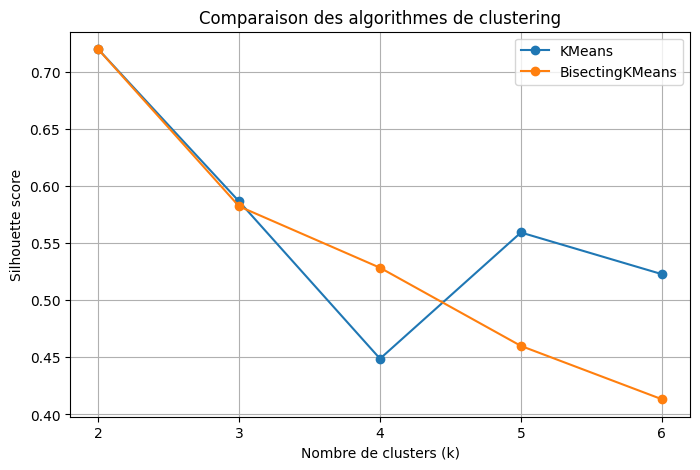

In [12]:
# ── Visualisation des résultats ─────────────────────────────────────────────
import pandas as pd
import matplotlib.pyplot as plt

# Convertir les résultats en DataFrame
df_kmeans = pd.DataFrame(kmeans_results)
df_bkm    = pd.DataFrame(bisecting_results)

# Style simple
plt.figure(figsize=(8,5))

# Courbe silhouette
plt.plot(df_kmeans["k"], df_kmeans["silhouette"], marker="o", label="KMeans")
plt.plot(df_bkm["k"], df_bkm["silhouette"], marker="o", label="BisectingKMeans")

plt.xlabel("Nombre de clusters (k)")
plt.ylabel("Silhouette score")
plt.title("Comparaison des algorithmes de clustering")
plt.xticks(K_RANGE)
plt.grid(True)
plt.legend()

plt.show()

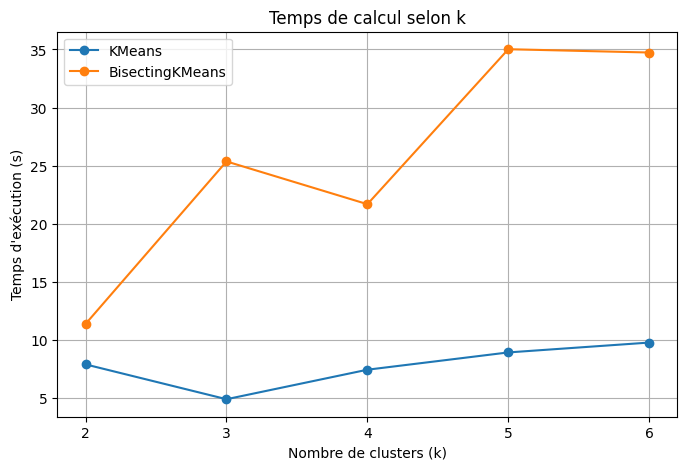

In [13]:
# ── Temps d'exécution ───────────────────────────────────────────────────────
plt.figure(figsize=(8,5))

plt.plot(df_kmeans["k"], df_kmeans["elapsed_s"], marker="o", label="KMeans")
plt.plot(df_bkm["k"], df_bkm["elapsed_s"], marker="o", label="BisectingKMeans")

plt.xlabel("Nombre de clusters (k)")
plt.ylabel("Temps d'exécution (s)")
plt.title("Temps de calcul selon k")
plt.xticks(K_RANGE)
plt.grid(True)
plt.legend()

plt.show()

Rendering clustering for k=2


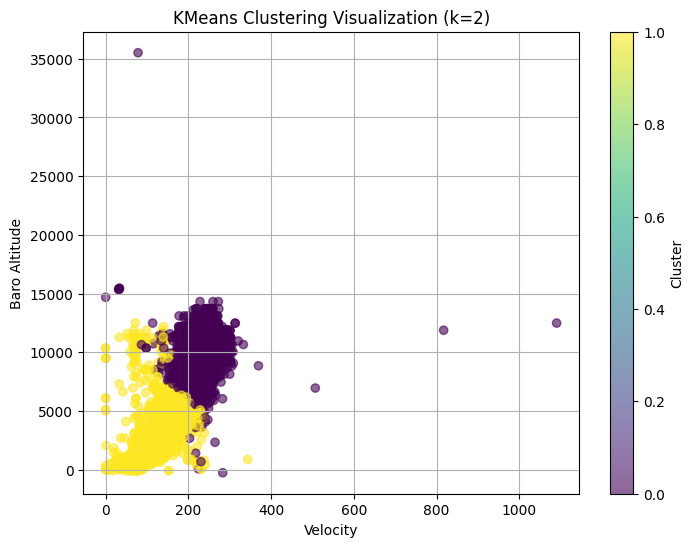

Rendering clustering for k=3


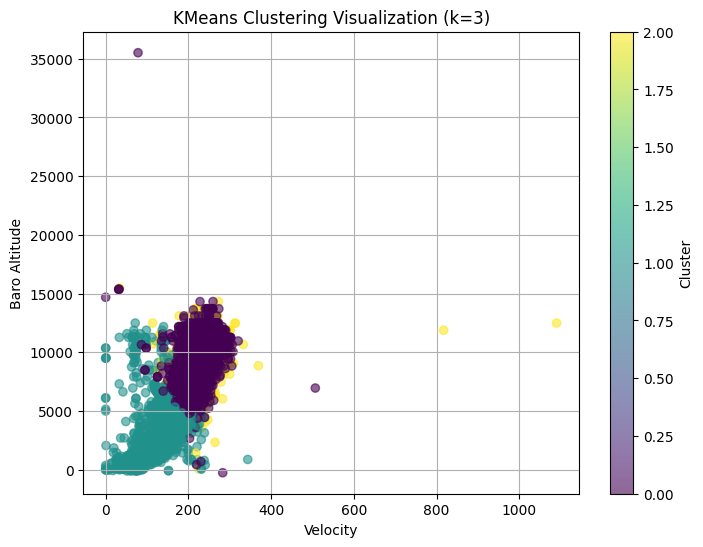

Rendering clustering for k=4


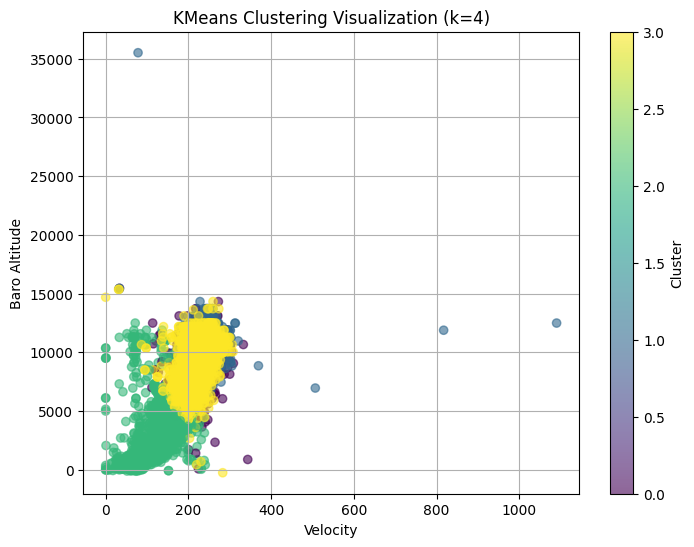

Rendering clustering for k=5


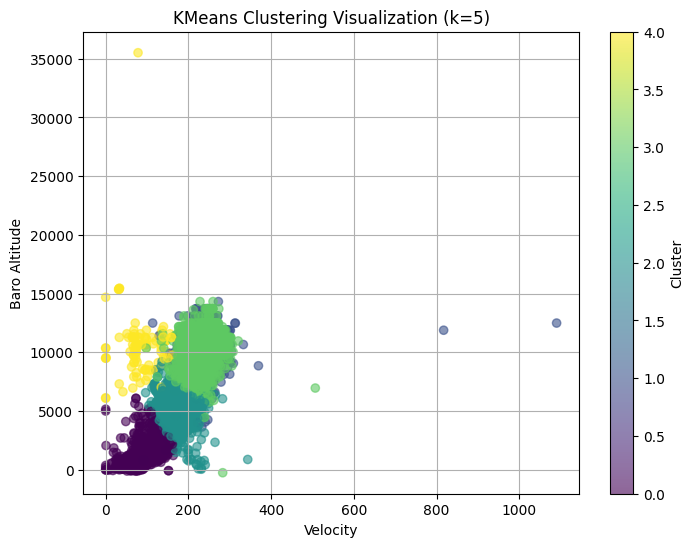

Rendering clustering for k=6


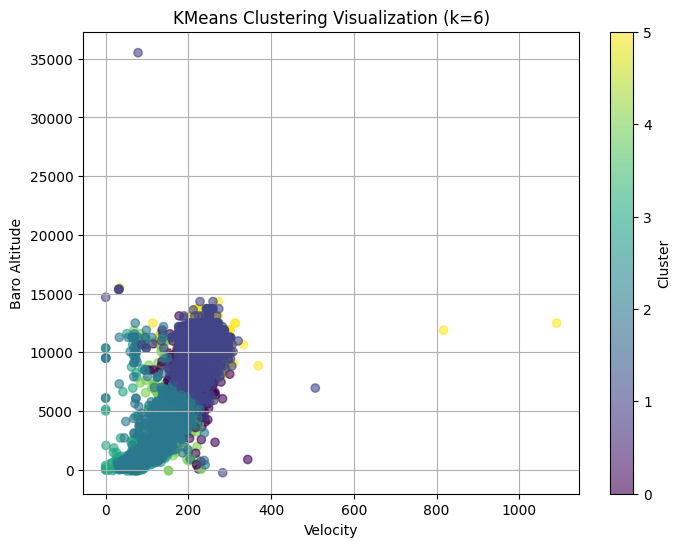

In [15]:
# ── Visualisation des clusters KMeans ──────────────────────────────────────
# Affichage des points colorés selon leur cluster
# On projette sur 2 dimensions : velocity vs baroaltitude

import matplotlib.pyplot as plt
import pandas as pd

# Pour éviter de charger 1M+ lignes dans matplotlib
SAMPLE_SIZE = 10000

for k in K_RANGE:

    print(f"Rendering clustering for k={k}")

    # Entraîner le modèle
    km_vis = KMeans(
        k=k,
        seed=SEED_BASE,
        maxIter=MAX_ITER,
        featuresCol="features",
        predictionCol="prediction"
    )

    model_vis = km_vis.fit(features_df)

    # Prédictions
    pred_df = model_vis.transform(features_df)

    # Garder uniquement quelques colonnes lisibles
    vis_df = (
        pred_df
        .select(
            "velocity",
            "baroaltitude",
            "prediction"
        )
        .sample(False, SAMPLE_SIZE / features_df.count(), seed=42)
        .toPandas()
    )

    # Figure
    plt.figure(figsize=(8,6))

    scatter = plt.scatter(
        vis_df["velocity"],
        vis_df["baroaltitude"],
        c=vis_df["prediction"],
        alpha=0.6
    )

    plt.xlabel("Velocity")
    plt.ylabel("Baro Altitude")
    plt.title(f"KMeans Clustering Visualization (k={k})")

    plt.colorbar(scatter, label="Cluster")

    plt.grid(True)

    plt.show()